<a href="https://www.kaggle.com/code/sonawanelalitsunil/multiclass-diabetes-classification-dataset?scriptVersionId=252256930" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/multiclass-diabetes-dataset/Multiclass Diabetes Dataset/Multiclass Diabetes Dataset.csv


## Title: Multiclass Diabetes Classification Dataset

## Description:
This dataset is designed for multiclass classification tasks to predict the stage or type of diabetes a patient may have. It includes various health-related features such as age, BMI, glucose level, insulin level, blood pressure, and lifestyle factors. Each record is labeled with a diabetes class, which could represent categories like non-diabetic, prediabetic, and diabetic. The dataset is useful for building and evaluating machine learning models in healthcare diagnostics, especially for early detection and classification of diabetes conditions.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/multiclass-diabetes-dataset/Multiclass Diabetes Dataset/Multiclass Diabetes Dataset.csv')

In [3]:
df.head()

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,Class
0,0,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,0
1,1,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,0
2,1,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,0
3,0,45,2.3,24,4.0,2.9,1.0,1.0,1.5,0.4,21.0,0
4,0,50,2.0,50,4.0,3.6,1.3,0.9,2.1,0.6,24.0,0


In [4]:
df.tail()

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,Class
259,0,61,24.0,401,7.0,4.3,2.9,0.4,2.7,1.3,30.0,2
260,0,61,24.0,401,7.0,4.3,2.9,0.4,2.7,1.3,36.6,2
261,1,60,20.8,800,9.0,2.3,1.1,0.9,0.9,0.5,33.0,2
262,1,56,20.8,800,9.0,4.6,2.0,1.2,2.5,0.9,35.0,2
263,1,58,20.8,800,9.1,6.6,2.9,1.1,4.3,1.3,33.0,2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264 entries, 0 to 263
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  264 non-null    int64  
 1   AGE     264 non-null    int64  
 2   Urea    264 non-null    float64
 3   Cr      264 non-null    int64  
 4   HbA1c   264 non-null    float64
 5   Chol    264 non-null    float64
 6   TG      264 non-null    float64
 7   HDL     264 non-null    float64
 8   LDL     264 non-null    float64
 9   VLDL    264 non-null    float64
 10  BMI     264 non-null    float64
 11  Class   264 non-null    int64  
dtypes: float64(8), int64(4)
memory usage: 24.9 KB


In [6]:
df.describe()

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,Class
count,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000
mean,0.545455,49.522727,5.671515,85.806818,6.862727,4.594394,2.151894,1.182879,2.530871,1.479167,26.626856,1.121212
std,0.498875,10.127301,4.002837,99.400047,2.544604,1.289062,1.265841,0.455591,1.000173,3.099856,5.093652,0.914857
min,0.000000,25.000000,1.100000,6.000000,0.900000,0.000000,0.600000,0.400000,0.300000,0.200000,19.000000,0.000000
25%,0.000000,43.000000,3.600000,46.000000,5.000000,3.875000,1.300000,0.900000,1.800000,0.675000,23.000000,0.000000
50%,1.000000,50.000000,4.700000,61.000000,6.100000,4.500000,1.800000,1.100000,2.500000,0.900000,25.000000,1.000000
75%,1.000000,55.250000,6.100000,82.250000,8.200000,5.300000,2.725000,1.325000,3.200000,1.300000,30.000000,2.000000
max,1.000000,77.000000,26.400000,800.000000,14.600000,9.500000,8.700000,4.000000,5.600000,31.800000,43.250000,2.000000


In [7]:
df.isnull().sum()

Gender    0
AGE       0
Urea      0
Cr        0
HbA1c     0
Chol      0
TG        0
HDL       0
LDL       0
VLDL      0
BMI       0
Class     0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

Gender      int64
AGE         int64
Urea      float64
Cr          int64
HbA1c     float64
Chol      float64
TG        float64
HDL       float64
LDL       float64
VLDL      float64
BMI       float64
Class       int64
dtype: object

In [10]:
df.shape

(264, 12)

In [11]:
df.columns

Index(['Gender', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL',
       'VLDL', 'BMI', 'Class'],
      dtype='object')

## Data visualizations

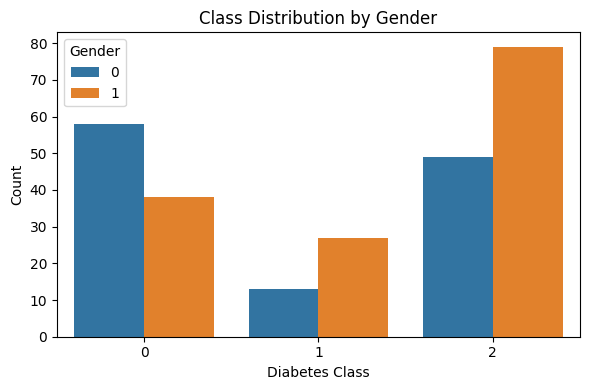

In [12]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Class', hue='Gender')
plt.title("Class Distribution by Gender")
plt.xlabel("Diabetes Class")
plt.ylabel("Count")
plt.legend(title="Gender")
plt.tight_layout()
plt.show()


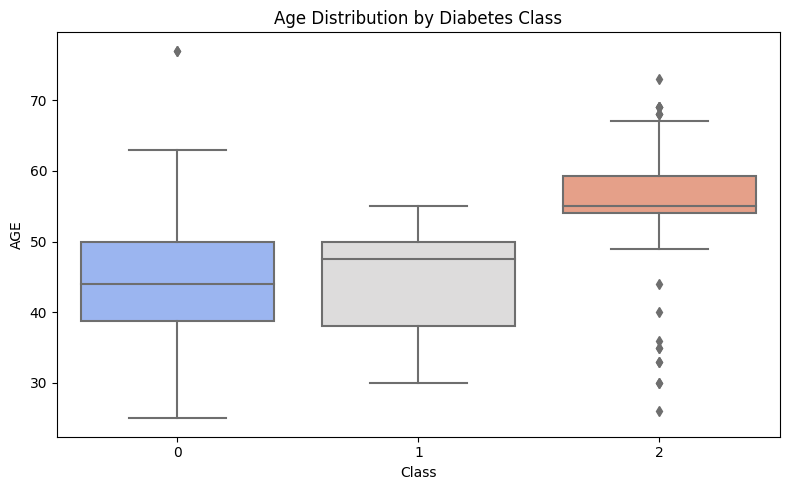

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Class', y='AGE', palette="coolwarm")
plt.title("Age Distribution by Diabetes Class")
plt.tight_layout()
plt.show()

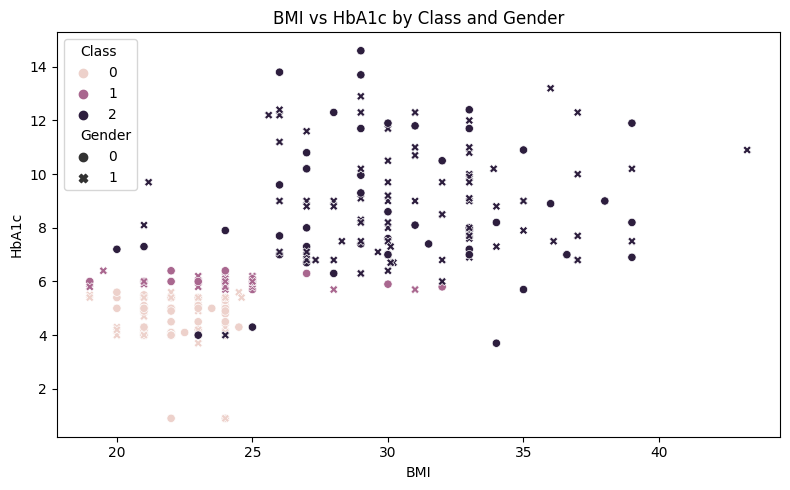

In [14]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='BMI', y='HbA1c', hue='Class', style='Gender')
plt.title("BMI vs HbA1c by Class and Gender")
plt.tight_layout()
plt.show()


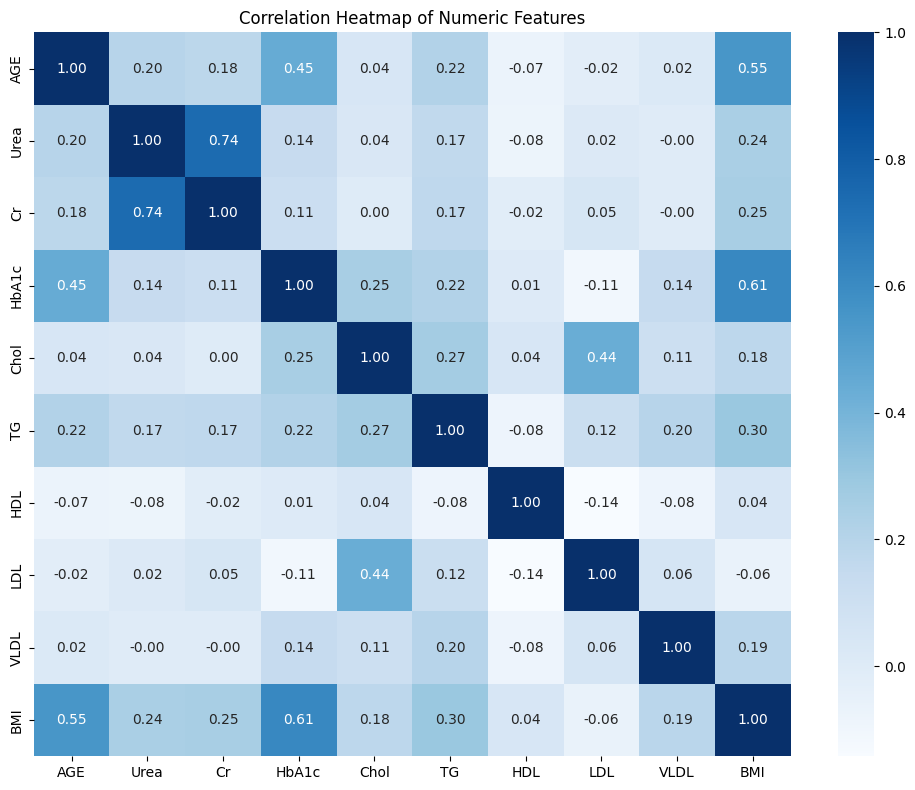

In [15]:
numeric_cols = ['AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI']
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

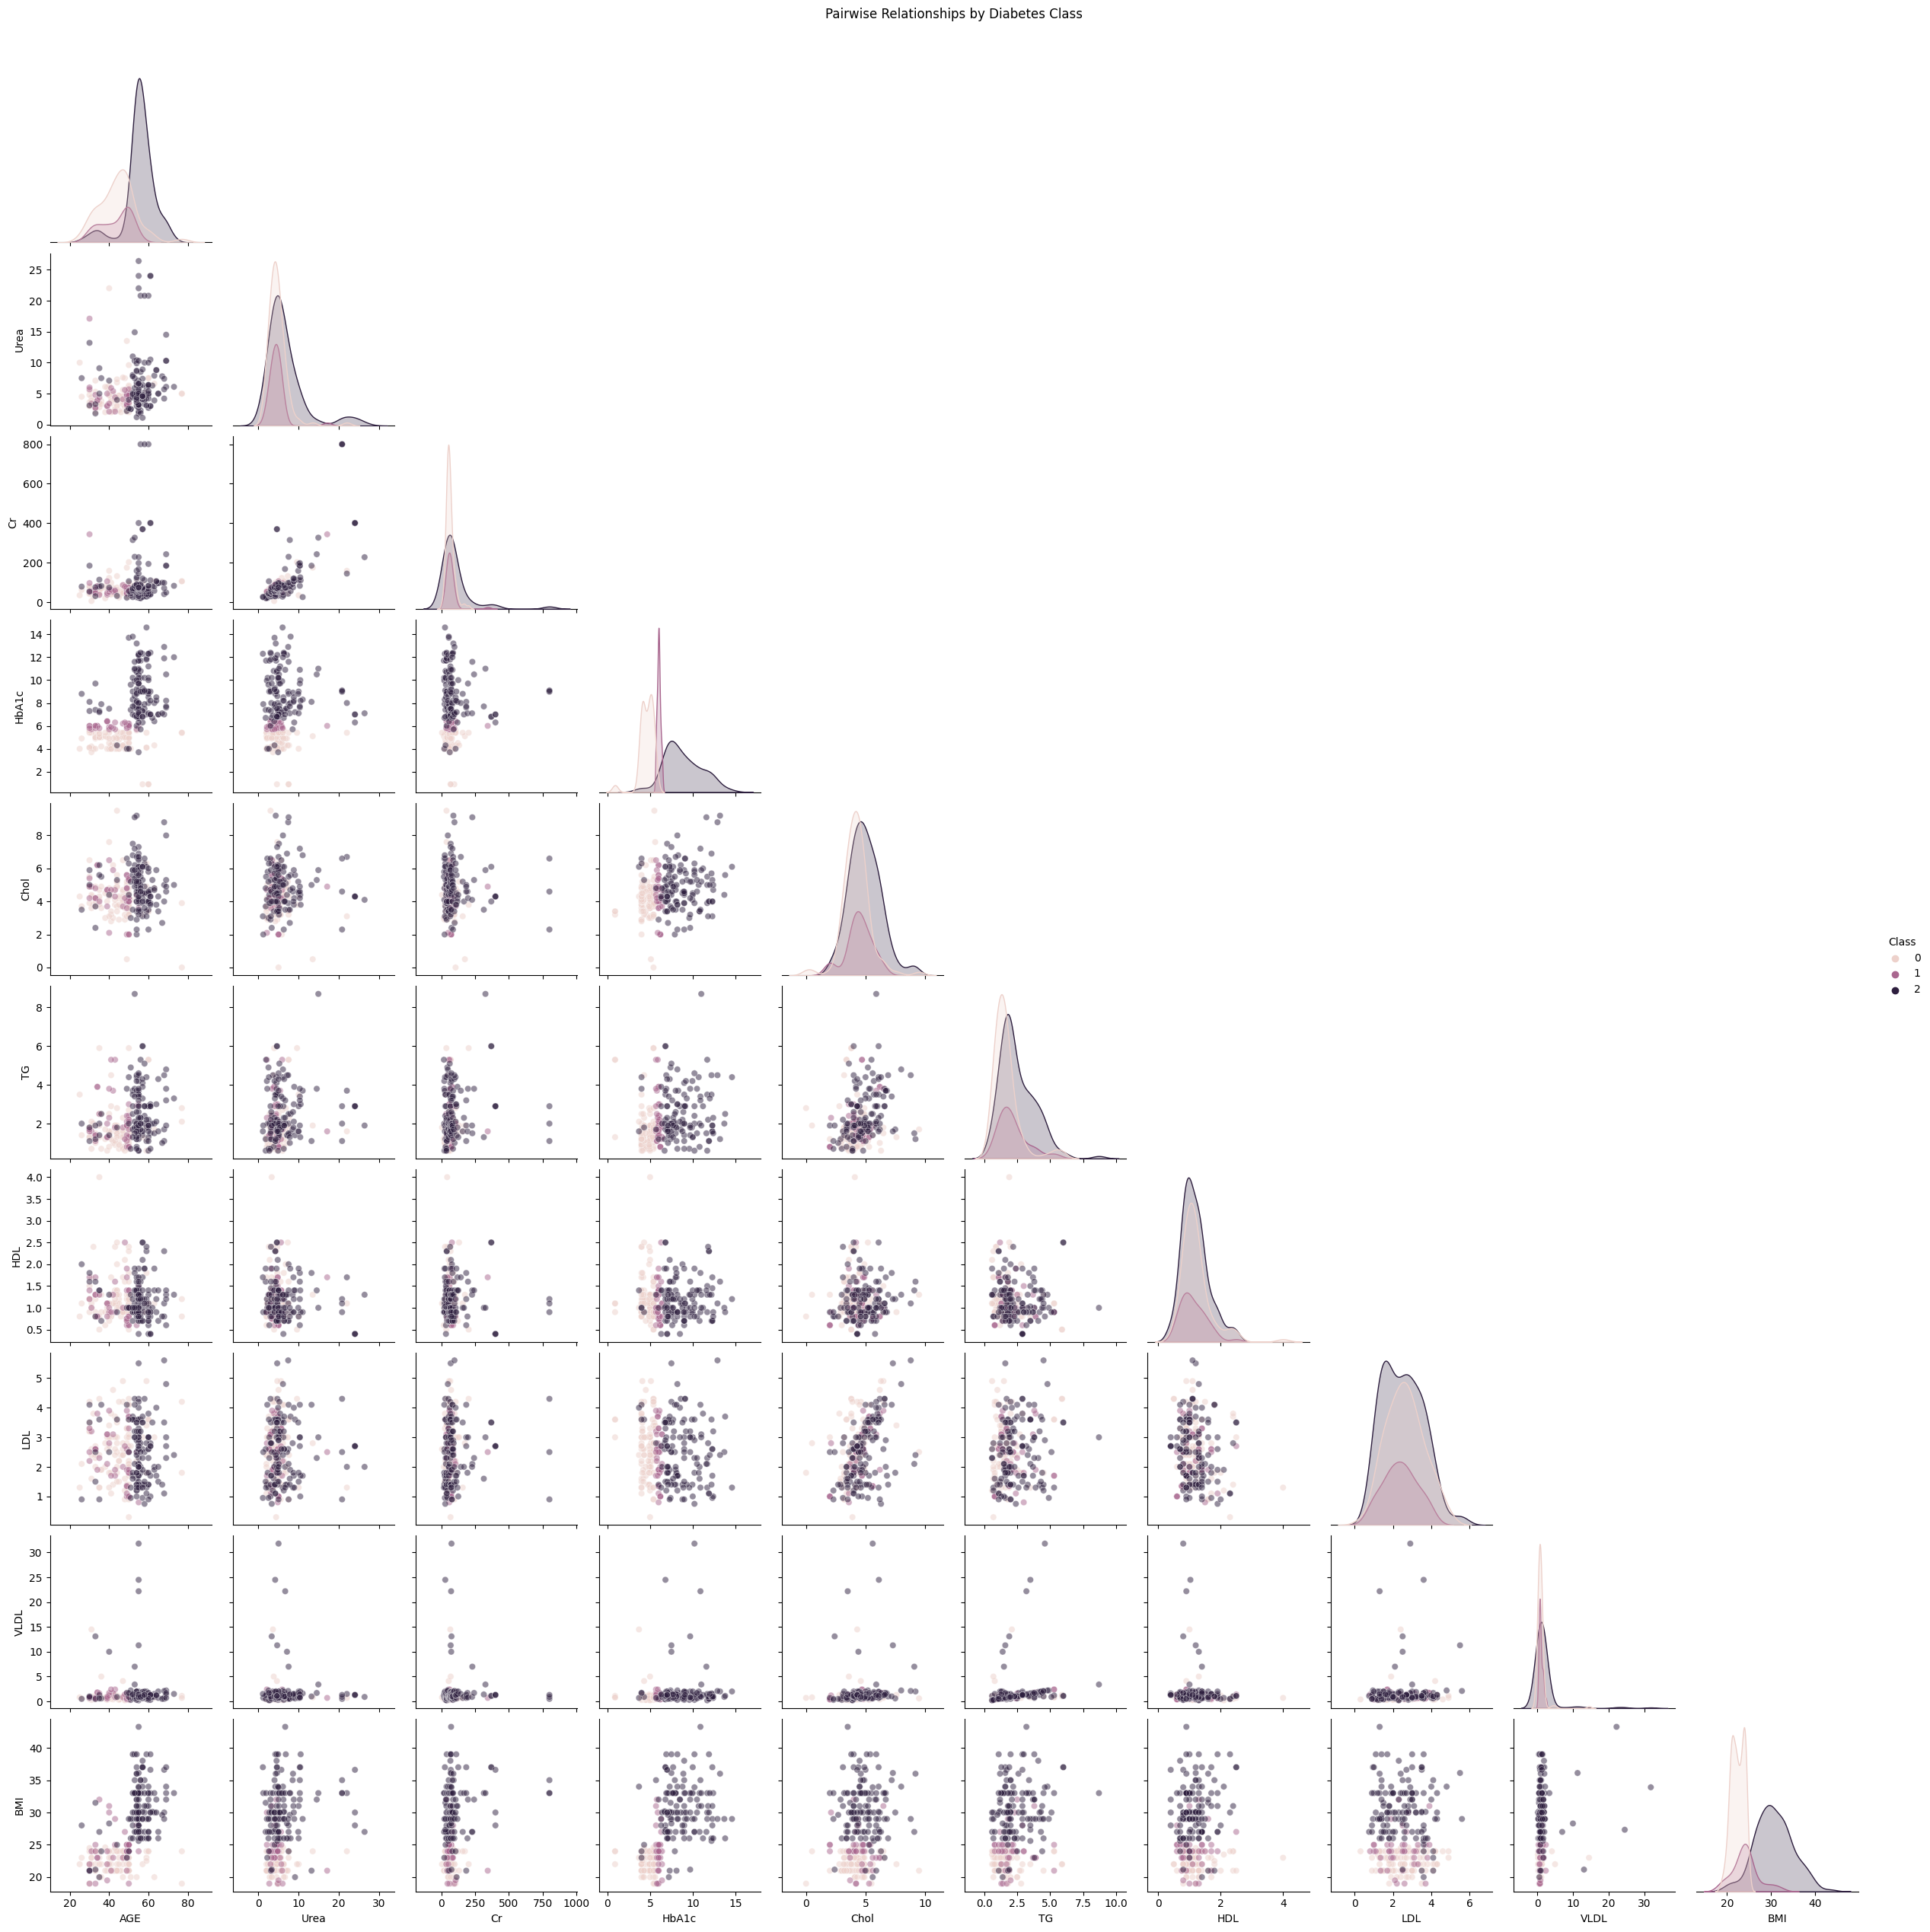

In [16]:
sns.pairplot(df[numeric_cols + ['Class']], hue="Class", corner=True, plot_kws={"alpha": 0.5})
plt.suptitle("Pairwise Relationships by Diabetes Class", y=1.02)
plt.show()

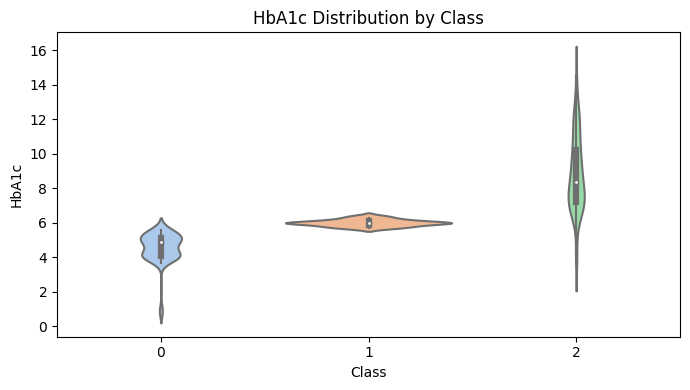

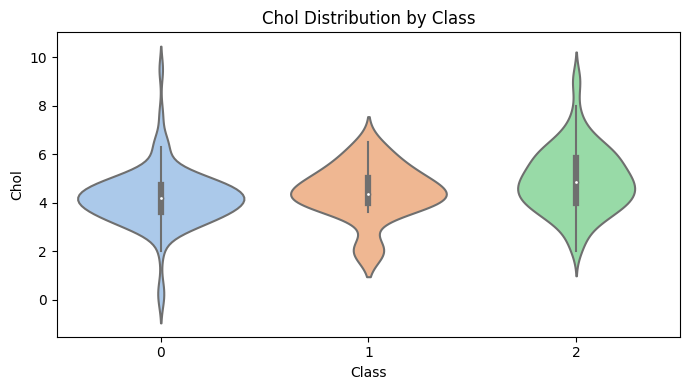

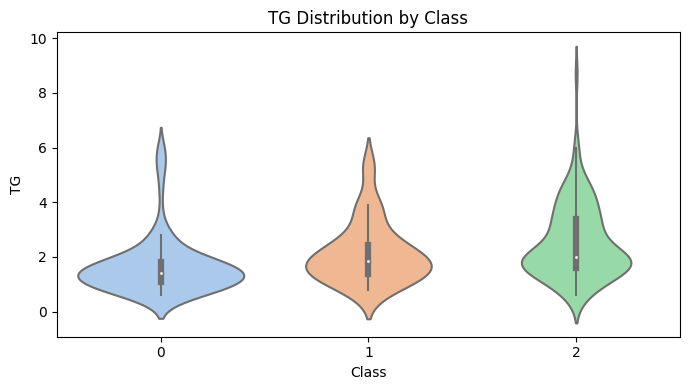

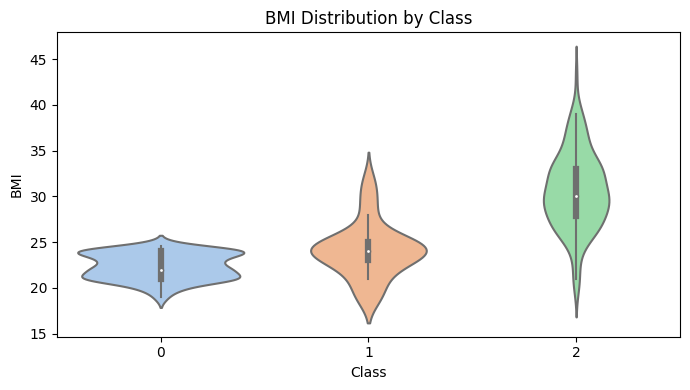

In [17]:
key_features = ['HbA1c', 'Chol', 'TG', 'BMI']
for feature in key_features:
    plt.figure(figsize=(7, 4))
    sns.violinplot(data=df, x='Class', y=feature, palette="pastel")
    plt.title(f"{feature} Distribution by Class")
    plt.tight_layout()
    plt.show()

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [19]:
# Label encode categorical features
le_gender = LabelEncoder()
df['Gender'] = le_gender.fit_transform(df['Gender'])

le_class = LabelEncoder()
df['Class'] = le_class.fit_transform(df['Class'])  # Multiclass encoding

# Define features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [20]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Support Vector Machine': SVC(),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

# Store accuracies
accuracy_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds) * 100
    accuracy_results[name] = acc


In [21]:
# Show accuracies sorted
print("Model Accuracies (%):")
for model, acc in sorted(accuracy_results.items(), key=lambda x: x[1], reverse=True):
    print(f"{model}: {acc:.2f}%")


Model Accuracies (%):
Random Forest: 98.11%
Decision Tree: 94.34%
Logistic Regression: 90.57%
Naive Bayes: 90.57%
Support Vector Machine: 77.36%
K-Nearest Neighbors: 75.47%


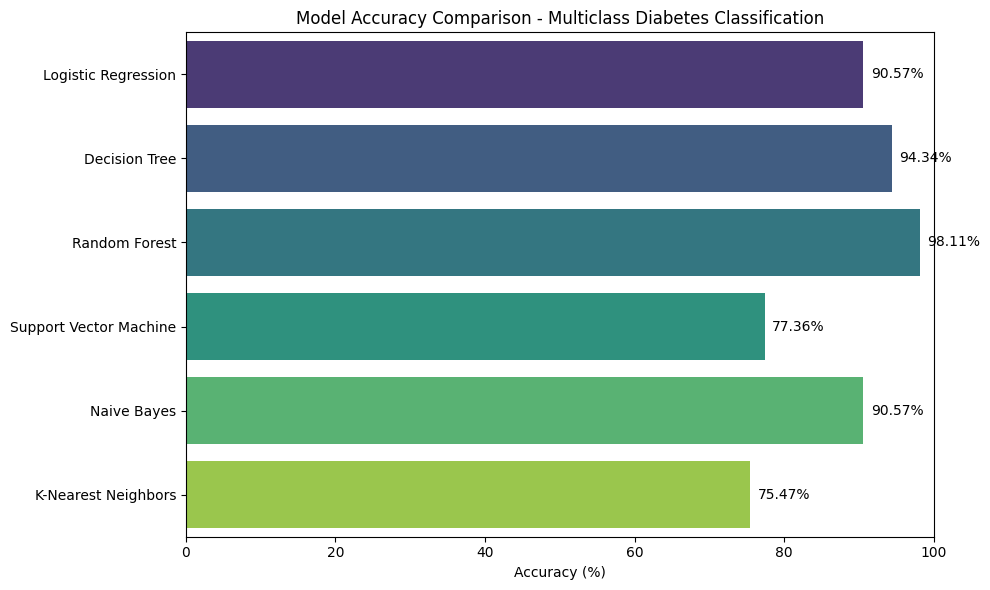

In [22]:
# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x=list(accuracy_results.values()), y=list(accuracy_results.keys()), palette="viridis")

plt.xlabel("Accuracy (%)")
plt.title("Model Accuracy Comparison - Multiclass Diabetes Classification")
plt.xlim(0, 100)

# Annotate bars
for index, value in enumerate(accuracy_results.values()):
    plt.text(value + 1, index, f"{value:.2f}%", va='center')

plt.tight_layout()
plt.show()


## thank you...pls upvote!!!